# Customer Churn EDA - Fuck

Objective: build a compact exploratory analysis for Kaggle Playground Series S6E3 customer churn data. The notebook focuses on data quality, target balance, churn patterns by customer attributes, numeric relationships, and train/test consistency.

Done means another teammate can use the findings to choose preprocessing, feature engineering, and model validation priorities without relying on hidden notebook state.


In [1]:
# Setup: imports and display options
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42


## Plan

- Confirm the train/test shape, schema, missing values, duplicated rows, and target format.
- Measure target imbalance because it affects metrics and validation.
- Compare churn rate across categorical groups to identify high-risk segments.
- Inspect numeric distributions and correlations with churn.
- Check simple engineered signals such as tenure buckets and charge intensity.
- Compare train and test distributions to catch drift before modeling.


## Optional data download

The README asks the team to store Kaggle files in `data/`. This cell is optional: it only downloads when `data/train.csv` is missing. It avoids hard-coded credentials and first tries the official competition endpoint, then a public dataset mirror.


In [2]:
# Optional: download data only if local CSV files are missing
from pathlib import Path
import shutil

candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([Path.cwd() / "data", Path("data"), Path("../data")])
existing_data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
local_data_dir = existing_data_dir or (Path.cwd().parent / "data" if Path.cwd().name.lower() == "eda" else Path.cwd() / "data")
if not (local_data_dir / "train.csv").exists():
    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError(
            "data/train.csv is missing and kagglehub is not installed. "
            "Install it with `pip install kagglehub` or manually download the Kaggle CSV files into data/."
        ) from exc

    downloaded_path = None
    download_errors = []
    for download_func, slug in [
        (kagglehub.competition_download, "playground-series-s6e3"),
        (kagglehub.dataset_download, "sarvesh85/playground-series-s6e3"),
    ]:
        try:
            downloaded_path = Path(download_func(slug))
            break
        except Exception as exc:
            download_errors.append(f"{slug}: {exc}")

    if downloaded_path is None:
        raise RuntimeError("Could not download data. " + " | ".join(download_errors))

    local_data_dir.mkdir(exist_ok=True)
    for filename in ["train.csv", "test.csv", "sample_submission.csv"]:
        source = downloaded_path / filename
        if source.exists():
            shutil.copy2(source, local_data_dir / filename)

print("Data directory ready.")
print(sorted(path.name for path in local_data_dir.glob("*.csv")))


Data directory ready.
['sample_submission.csv', 'test.csv', 'train.csv']


## 1. Load files and inspect the schema

This establishes the basic contract of the dataset. The target is `Churn`, while `id` is an identifier and should not be used as a predictive feature.


In [3]:
# Load train/test/sample files and show the first rows
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv") if (data_dir / "test.csv").exists() else None
sample_submission = (
    pd.read_csv(data_dir / "sample_submission.csv")
    if (data_dir / "sample_submission.csv").exists()
    else None
)

file_summary = pd.DataFrame({
    "file": ["train.csv", "test.csv", "sample_submission.csv"],
    "rows": [len(train), len(test) if test is not None else np.nan, len(sample_submission) if sample_submission is not None else np.nan],
    "columns": [train.shape[1], test.shape[1] if test is not None else np.nan, sample_submission.shape[1] if sample_submission is not None else np.nan],
})

display(file_summary)
display(train.head())


,file,rows,columns
0,train.csv,594194,21
1,test.csv,254655,20
2,sample_submission.csv,254655,2


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## 2. Data quality checks

The quick checks below look for missing values, duplicated IDs, duplicated full rows, unexpected target labels, and columns that appear only in train or test.


In [4]:
# Data quality checks
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv") if (data_dir / "test.csv").exists() else None
sample_submission = (
    pd.read_csv(data_dir / "sample_submission.csv")
    if (data_dir / "sample_submission.csv").exists()
    else None
)

expected_target = "Churn"
missing_by_column = train.isna().sum().sort_values(ascending=False)
quality_summary = pd.Series({
    "train_rows": len(train),
    "train_columns": train.shape[1],
    "test_rows": len(test) if test is not None else np.nan,
    "test_columns": test.shape[1] if test is not None else np.nan,
    "missing_cells_train": int(train.isna().sum().sum()),
    "duplicated_rows_train": int(train.duplicated().sum()),
    "duplicated_id_train": int(train["id"].duplicated().sum()) if "id" in train else np.nan,
    "target_unique_values": ", ".join(map(str, sorted(train[expected_target].unique()))) if expected_target in train else "missing",
})

train_only_columns = sorted(set(train.columns) - set(test.columns)) if test is not None else []
test_only_columns = sorted(set(test.columns) - set(train.columns)) if test is not None else []

display(quality_summary.to_frame("value"))
display(pd.DataFrame({"train_only_columns": pd.Series(train_only_columns), "test_only_columns": pd.Series(test_only_columns)}))
display(missing_by_column[missing_by_column > 0].to_frame("missing_count"))


,value
train_rows,594194
train_columns,21
test_rows,254655
test_columns,20
missing_cells_train,0
duplicated_rows_train,0
duplicated_id_train,0
target_unique_values,"No, Yes"


,train_only_columns,test_only_columns
0,Churn,NaN


,missing_count


## 3. Target balance

Churn is a binary classification target. The positive class is usually the smaller class, so accuracy alone can be misleading; ROC-AUC, PR-AUC, recall, and calibration are better follow-up metrics.


,Churn,count,percent
0,No,460377,77.479241
1,Yes,133817,22.520759


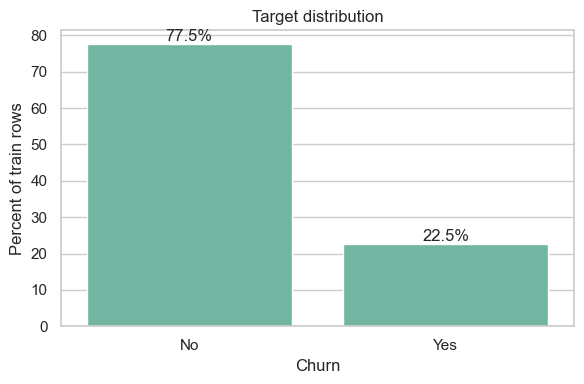

In [5]:
# Target distribution
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

churn_counts = train["Churn"].value_counts().rename_axis("Churn").reset_index(name="count")
churn_counts["percent"] = churn_counts["count"] / len(train) * 100

display(churn_counts)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=churn_counts, x="Churn", y="percent", ax=ax)
ax.set_title("Target distribution")
ax.set_ylabel("Percent of train rows")
ax.set_xlabel("Churn")
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f"{height:.1f}%", (patch.get_x() + patch.get_width() / 2, height), ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 4. Categorical feature overview

Most columns are categorical. This table highlights cardinality and dominant values, which helps decide whether simple one-hot encoding is enough or whether rare-category handling is needed.


In [6]:
# Categorical cardinality and dominant categories
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

categorical_cols = [col for col in train.select_dtypes(include="object").columns if col != "Churn"]
rows = []
for col in categorical_cols:
    counts = train[col].value_counts(dropna=False)
    rows.append({
        "feature": col,
        "unique_values": train[col].nunique(dropna=False),
        "top_value": counts.index[0],
        "top_value_percent": counts.iloc[0] / len(train) * 100,
        "rare_values_under_1pct": int((counts / len(train) < 0.01).sum()),
    })

cat_summary = pd.DataFrame(rows).sort_values(["unique_values", "feature"])
display(cat_summary)


,feature,unique_values,top_value,top_value_percent,rare_values_under_1pct
2,Dependents,2,No,69.735137,0
13,PaperlessBilling,2,Yes,61.525192,0
1,Partner,2,Yes,52.096453,0
3,PhoneService,2,Yes,93.890716,0
0,gender,2,Female,50.276172,0
12,Contract,3,Month-to-month,50.306466,0
8,DeviceProtection,3,No,41.632362,0
5,InternetService,3,Fiber optic,45.841257,0
4,MultipleLines,3,No,47.692168,0
7,OnlineBackup,3,No,42.087769,0


## 5. Churn rate by categorical groups

For modeling, the most useful categorical fields are the ones where churn rate changes strongly between categories. The table reports the highest-risk and lowest-risk category for each feature.


In [7]:
# Churn rate spread by categorical feature
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

train = train.assign(churn_flag=train["Churn"].eq("Yes").astype(int))
categorical_cols = [col for col in train.select_dtypes(include="object").columns if col != "Churn"]
rows = []
for col in categorical_cols:
    grouped = train.groupby(col, dropna=False)["churn_flag"].agg(churn_rate="mean", rows="size")
    grouped = grouped[grouped["rows"] >= 100]
    high = grouped.sort_values("churn_rate", ascending=False).iloc[0]
    low = grouped.sort_values("churn_rate", ascending=True).iloc[0]
    rows.append({
        "feature": col,
        "highest_risk_value": high.name,
        "highest_risk_rate": high["churn_rate"] * 100,
        "highest_risk_rows": int(high["rows"]),
        "lowest_risk_value": low.name,
        "lowest_risk_rate": low["churn_rate"] * 100,
        "lowest_risk_rows": int(low["rows"]),
        "spread_pp": (high["churn_rate"] - low["churn_rate"]) * 100,
    })

risk_spread = pd.DataFrame(rows).sort_values("spread_pp", ascending=False)
display(risk_spread.round({"highest_risk_rate": 2, "lowest_risk_rate": 2, "spread_pp": 2}))


,feature,highest_risk_value,highest_risk_rate,highest_risk_rows,lowest_risk_value,lowest_risk_rate,lowest_risk_rows,spread_pp
14,PaymentMethod,Electronic check,48.91,215372,Credit card (automatic),6.93,133705,41.97
12,Contract,Month-to-month,42.05,298918,Two year,1.00,186943,41.06
5,InternetService,Fiber optic,41.54,272386,No,1.43,140727,40.11
6,OnlineSecurity,No,40.61,289474,No internet service,1.43,140727,39.18
9,TechSupport,No,40.16,288571,No internet service,1.43,140727,38.73
7,OnlineBackup,No,39.10,250083,No internet service,1.43,140727,37.67
8,DeviceProtection,No,38.06,247377,No internet service,1.43,140727,36.63
11,StreamingMovies,No,29.93,212032,No internet service,1.43,140727,28.50
10,StreamingTV,No,29.74,213166,No internet service,1.43,140727,28.31
13,PaperlessBilling,Yes,31.94,365579,No,7.46,228615,24.48


## 6. Visual check of key churn segments

These plots show the categories that usually matter in telecom churn: contract type, internet service, payment method, billing preference, dependents, and support/security services.


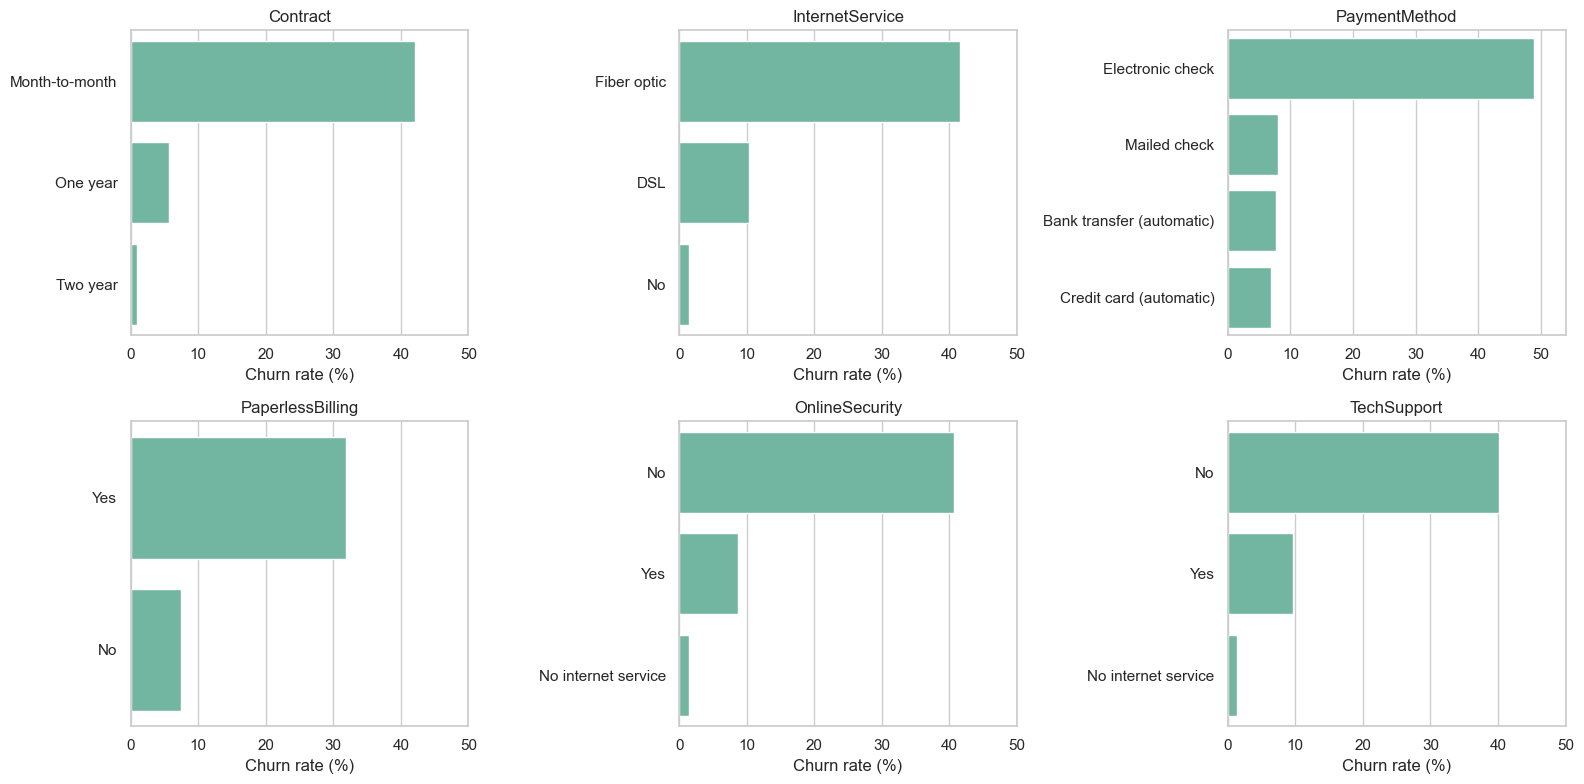

In [8]:
# Plot churn rates for selected categorical features
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

train = train.assign(churn_flag=train["Churn"].eq("Yes").astype(int))
selected_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "OnlineSecurity",
    "TechSupport",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feature in zip(axes.ravel(), selected_features):
    plot_data = (
        train.groupby(feature, dropna=False)["churn_flag"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index(name="churn_rate")
    )
    sns.barplot(data=plot_data, y=feature, x="churn_rate", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Churn rate (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(50, plot_data["churn_rate"].max() + 5))
plt.tight_layout()
plt.show()


## 7. Numeric feature summary

The numeric fields describe tenure and charges. Directionally, short tenure and high monthly charges are expected to increase churn risk, while high total charges often reflect longer tenure and lower churn.


In [9]:
# Numeric summary and correlation with churn
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

train = train.assign(churn_flag=train["Churn"].eq("Yes").astype(int))
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

describe_table = train[numeric_cols].describe().T
corr_table = (
    train[numeric_cols + ["churn_flag"]]
    .corr(numeric_only=True)["churn_flag"]
    .drop("churn_flag")
    .sort_values(key=lambda series: series.abs(), ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", "churn_flag": "corr_with_churn"})
)

display(describe_table.round(2))
display(corr_table.round(3))


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,594194.0,0.11,0.32,0.00,0.00,0.00,0.0,1.00
tenure,594194.0,36.58,25.06,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,594194.0,65.87,31.07,18.25,29.90,74.10,90.8,118.75
TotalCharges,594194.0,2494.38,2353.92,18.80,639.65,1433.65,4263.8,8684.80


,feature,corr_with_churn
0,tenure,-0.418
1,MonthlyCharges,0.273
2,SeniorCitizen,0.236
3,TotalCharges,-0.218


## 8. Numeric distributions by churn

The plots use a capped sample for speed. They are meant to show separation, not exact density estimation.


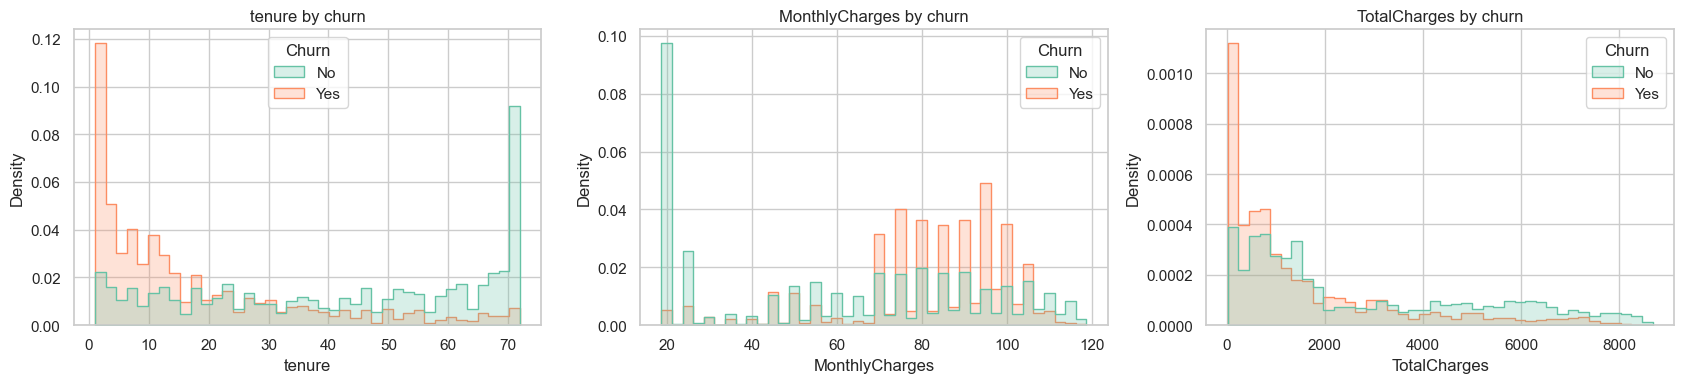

In [10]:
# Numeric distribution plots by target
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

plot_sample = train.sample(n=min(80000, len(train)), random_state=RANDOM_STATE)
features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, feature in zip(axes, features):
    sns.histplot(
        data=plot_sample,
        x=feature,
        hue="Churn",
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(f"{feature} by churn")
plt.tight_layout()
plt.show()


## 9. Tenure and charge interaction

Churn is often strongest among newer customers with expensive monthly plans. Binning tenure and monthly charges makes that relationship easier to inspect before feature engineering.


monthly_charge_quartile,Q1 lowest,Q2,Q3,Q4 highest
tenure_bucket,,,,
1-6,15.04,47.56,77.98,87.05
7-12,4.63,26.95,60.67,77.37
13-24,2.72,14.77,42.29,61.81
25-48,1.45,6.86,24.64,41.89
49-72,0.36,1.78,2.68,12.04


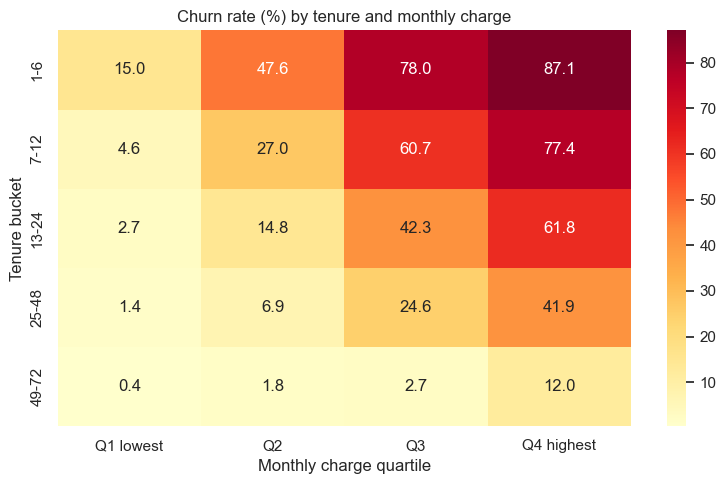

In [11]:
# Churn heatmap by tenure bucket and monthly charge quartile
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

train = train.assign(churn_flag=train["Churn"].eq("Yes").astype(int))
train["tenure_bucket"] = pd.cut(
    train["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["1-6", "7-12", "13-24", "25-48", "49-72"],
    include_lowest=True,
)
train["monthly_charge_quartile"] = pd.qcut(
    train["MonthlyCharges"],
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
    duplicates="drop",
)

heatmap_data = (
    train.pivot_table(
        index="tenure_bucket",
        columns="monthly_charge_quartile",
        values="churn_flag",
        aggfunc="mean",
        observed=False,
    )
    .mul(100)
)

display(heatmap_data.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Churn rate (%) by tenure and monthly charge")
ax.set_xlabel("Monthly charge quartile")
ax.set_ylabel("Tenure bucket")
plt.tight_layout()
plt.show()


## 10. Simple derived charge signals

`TotalCharges` is related to `tenure * MonthlyCharges`, but discounts, rounding, and synthetic generation can create useful residual signals. This check looks for whether charge-derived ratios are plausible.


In [12]:
# Derived charge features and sanity ranges
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

charge_view = train[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].copy()
charge_view["estimated_total"] = charge_view["tenure"] * charge_view["MonthlyCharges"]
charge_view["total_charge_gap"] = charge_view["TotalCharges"] - charge_view["estimated_total"]
charge_view["avg_charge_per_tenure"] = charge_view["TotalCharges"] / charge_view["tenure"].replace(0, np.nan)
charge_view["churn_flag"] = charge_view["Churn"].eq("Yes").astype(int)

summary = charge_view[["estimated_total", "total_charge_gap", "avg_charge_per_tenure"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
corr = (
    charge_view[["total_charge_gap", "avg_charge_per_tenure", "churn_flag"]]
    .corr(numeric_only=True)["churn_flag"]
    .drop("churn_flag")
    .sort_values(key=lambda series: series.abs(), ascending=False)
)

display(summary.round(2))
display(corr.to_frame("corr_with_churn").round(3))


,count,mean,std,min,1%,5%,50%,95%,99%,max
estimated_total,594194.0,2505.79,2375.91,18.80,35.90,79.00,1438.50,7329.30,8254.80,8550.0
total_charge_gap,594194.0,-11.41,298.75,-7369.25,-911.06,-423.87,0.00,356.72,789.90,7308.3
avg_charge_per_tenure,594194.0,66.56,39.97,0.75,17.98,19.33,73.37,108.64,116.73,1260.8


,corr_with_churn
avg_charge_per_tenure,0.238
total_charge_gap,0.037


## 11. Train/test distribution comparison

This helps catch features where the public test set differs from train. Large differences should be handled carefully during validation and preprocessing.


In [13]:
# Numeric and categorical train/test drift checks
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv") if (data_dir / "test.csv").exists() else None
sample_submission = (
    pd.read_csv(data_dir / "sample_submission.csv")
    if (data_dir / "sample_submission.csv").exists()
    else None
)
if test is None:
    raise FileNotFoundError("test.csv is required for train/test drift checks.")

numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
numeric_drift = []
for col in numeric_cols:
    train_mean = train[col].mean()
    test_mean = test[col].mean()
    train_std = train[col].std(ddof=0)
    numeric_drift.append({
        "feature": col,
        "train_mean": train_mean,
        "test_mean": test_mean,
        "mean_diff": test_mean - train_mean,
        "mean_diff_in_train_std": (test_mean - train_mean) / train_std if train_std else np.nan,
    })

cat_cols = [col for col in train.select_dtypes(include="object").columns if col in test.columns and col != "Churn"]
cat_drift = []
for col in cat_cols:
    train_dist = train[col].value_counts(normalize=True, dropna=False)
    test_dist = test[col].value_counts(normalize=True, dropna=False)
    values = sorted(set(train_dist.index).union(set(test_dist.index)), key=str)
    max_abs_diff = max(abs(train_dist.get(value, 0) - test_dist.get(value, 0)) for value in values)
    cat_drift.append({
        "feature": col,
        "unique_train": train[col].nunique(dropna=False),
        "unique_test": test[col].nunique(dropna=False),
        "max_category_share_diff_pp": max_abs_diff * 100,
    })

display(pd.DataFrame(numeric_drift).round(4))
display(pd.DataFrame(cat_drift).sort_values("max_category_share_diff_pp", ascending=False).round(3))


,feature,train_mean,test_mean,mean_diff,mean_diff_in_train_std
0,SeniorCitizen,0.1141,0.1136,-0.0005,-0.0015
1,tenure,36.5773,37.2797,0.7025,0.0280
2,MonthlyCharges,65.8662,66.1308,0.2646,0.0085
3,TotalCharges,2494.3771,2544.6174,50.2403,0.0213


,feature,unique_train,unique_test,max_category_share_diff_pp
1,Partner,2,2,0.800
12,Contract,3,3,0.745
7,OnlineBackup,3,3,0.698
11,StreamingMovies,3,3,0.607
9,TechSupport,3,3,0.600
6,OnlineSecurity,3,3,0.537
10,StreamingTV,3,3,0.533
8,DeviceProtection,3,3,0.508
4,MultipleLines,3,3,0.500
14,PaymentMethod,4,4,0.467


## 12. Consistency checks for service columns

Several columns use the value `No internet service`. These checks verify that the dependent service columns agree with `InternetService == No`.


In [14]:
# Service consistency checks
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

internet_dependent_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]
phone_dependent_cols = ["MultipleLines"]

checks = {
    "tenure_less_than_1": int((train["tenure"] < 1).sum()),
    "monthly_charges_non_positive": int((train["MonthlyCharges"] <= 0).sum()),
    "total_charges_non_positive": int((train["TotalCharges"] <= 0).sum()),
    "internet_no_but_service_not_no_internet": int(
        train.loc[train["InternetService"].eq("No"), internet_dependent_cols]
        .ne("No internet service")
        .any(axis=1)
        .sum()
    ),
    "internet_yes_but_service_no_internet": int(
        train.loc[~train["InternetService"].eq("No"), internet_dependent_cols]
        .eq("No internet service")
        .any(axis=1)
        .sum()
    ),
    "phone_no_but_multiple_lines_not_no_phone": int(
        train.loc[train["PhoneService"].eq("No"), phone_dependent_cols]
        .ne("No phone service")
        .any(axis=1)
        .sum()
    ),
    "phone_yes_but_multiple_lines_no_phone": int(
        train.loc[train["PhoneService"].eq("Yes"), phone_dependent_cols]
        .eq("No phone service")
        .any(axis=1)
        .sum()
    ),
}

display(pd.Series(checks).to_frame("rows"))


,rows
tenure_less_than_1,0
monthly_charges_non_positive,0
total_charges_non_positive,0
internet_no_but_service_not_no_internet,0
internet_yes_but_service_no_internet,0
phone_no_but_multiple_lines_not_no_phone,0
phone_yes_but_multiple_lines_no_phone,0


## 13. EDA summary for modeling

Use this final cell as a copyable handoff to the feature/modeling teammates. It recomputes the core findings from raw data so it does not depend on prior cells.


In [15]:
# Copyable EDA findings
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

raw_column_count = int(train.shape[1])
train = train.assign(churn_flag=train["Churn"].eq("Yes").astype(int))
key_segments = {}
for feature in ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "PaperlessBilling", "Dependents"]:
    rates = train.groupby(feature)["churn_flag"].mean().sort_values(ascending=False).mul(100)
    key_segments[feature] = {
        "highest_churn": f"{rates.index[0]} ({rates.iloc[0]:.2f}%)",
        "lowest_churn": f"{rates.index[-1]} ({rates.iloc[-1]:.2f}%)",
    }

eda_findings = {
    "rows": int(len(train)),
    "columns": raw_column_count,
    "positive_churn_rate_percent": float(round(train["churn_flag"].mean() * 100, 2)),
    "missing_cells": int(train.isna().sum().sum()),
    "duplicated_rows": int(train.duplicated().sum()),
    "strong_numeric_signals": (
        train[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "churn_flag"]]
        .corr(numeric_only=True)["churn_flag"]
        .drop("churn_flag")
        .sort_values(key=lambda series: series.abs(), ascending=False)
        .round(3)
        .to_dict()
    ),
    "key_categorical_segments": key_segments,
    "modeling_notes": [
        "Drop id from features; it is an identifier.",
        "Treat Churn == Yes as the positive class.",
        "Use stratified validation because churn is imbalanced.",
        "High-signal categories include contract, internet service, payment method, online security, tech support, and paperless billing.",
        "Consider tenure buckets, monthly charge buckets, and charge residual features after validating leakage risk.",
    ],
}

eda_findings


{'rows': 594194,
 'columns': 21,
 'positive_churn_rate_percent': 22.52,
 'missing_cells': 0,
 'duplicated_rows': 0,
 'strong_numeric_signals': {'tenure': -0.418,
  'MonthlyCharges': 0.273,
  'SeniorCitizen': 0.236,
  'TotalCharges': -0.218},
 'key_categorical_segments': {'Contract': {'highest_churn': 'Month-to-month (42.05%)',
   'lowest_churn': 'Two year (1.00%)'},
  'InternetService': {'highest_churn': 'Fiber optic (41.54%)',
   'lowest_churn': 'No (1.43%)'},
  'PaymentMethod': {'highest_churn': 'Electronic check (48.91%)',
   'lowest_churn': 'Credit card (automatic) (6.93%)'},
  'OnlineSecurity': {'highest_churn': 'No (40.61%)',
   'lowest_churn': 'No internet service (1.43%)'},
  'TechSupport': {'highest_churn': 'No (40.16%)',
   'lowest_churn': 'No internet service (1.43%)'},
  'PaperlessBilling': {'highest_churn': 'Yes (31.94%)',
   'lowest_churn': 'No (7.46%)'},
  'Dependents': {'highest_churn': 'No (29.14%)',
   'lowest_churn': 'Yes (7.28%)'}},
 'modeling_notes': ['Drop id from

## Next steps

- Share the high-signal categorical columns with the feature engineering owner.
- For modeling, compare a simple one-hot baseline against target/frequency encoding only inside cross-validation folds.
- Keep validation stratified by `Churn`; report ROC-AUC and PR-AUC, not only accuracy.
- Before final training, re-run train/test drift checks after any preprocessing pipeline changes.
